# Model performance

Leave-one-country-out performance for all ten fitted model variants, the check that each reproduces
its shipped pickle, and the published performance figure regenerated in the project palette.

The computation lives in `src/model_performance.py`. Read `doc/modelling.md` first if the variant
names are unfamiliar — three of them do not mean what they say (D37).

In [1]:
import sys
from pathlib import Path

# put src/ on the path — this notebook lives in src/analysis_notebooks/
SRC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'params.py').exists())
sys.path.insert(0, str(SRC))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import model_performance as mp
import params
import plotting as plot

NOTEBOOK = '02_model_performance'
CFG = params.FINAL_MODEL

OUTCOME_LABEL = {'ggi': 'GGI', 'wom': 'Women level', 'men': 'Men level'}
VARIANT_LABEL = {'online_with_CIS': 'Online', 'offline_with_CIS': 'Offline',
                 'combined_with_CIS': 'Combined'}

print('production variant:', CFG['model_type'])
print('figure variants   :', params.FIGURE_VARIANTS)

production variant: combined_with_CIS
figure variants   : ['online_with_CIS', 'offline_with_CIS', 'combined_with_CIS']


## 1. What each variant actually is

All ten read the same file and differ in two things: whether the ITU rows are kept, and the
regressor list. `_with_CIS` means **keep the ITU rows** — it does not select CIS countries.

In [2]:
pd.DataFrame([
    {'variant': v, 'keep_itu': c['keep_itu'], 'align': c.get('align', False),
     'spec': ' + '.join(c['spec']),
     'production': v == CFG['model_type']}
    for v, c in params.MODEL_VARIANTS.items()
])

,variant,keep_itu,align,spec,production
0,online,False,False,fb_18_999_men + fb_18_999_wom + fb_18_999_r,False
1,offline,False,False,hdi + gdi + gdp_pcap + year,False
2,combined,False,False,fb_18_999_men + fb_18_999_wom + fb_18_999_r + ...,False
3,combined_top_shaps_no_fertility,False,False,gggi_ggi + se_r + hdi + gdp_pcap + year + fb_1...,False
4,online_with_CIS,True,False,fb_18_999_men + fb_18_999_wom + fb_18_999_r,False
5,offline_with_CIS,True,False,hdi + gdi + gdp_pcap + year,False
6,combined_with_CIS,True,False,fb_18_999_men + fb_18_999_wom + fb_18_999_r + ...,True
7,online_with_CIS_align,True,True,fb_18_999_r,False
8,offline_with_CIS_align,True,True,hdi + gdi + gdp_pcap + year,False
9,combined_with_CIS_align,True,True,hdi + gdi + gdp_pcap + year + fb_18_999_r,False


## 2. Run the audit

Refits every variant, computes LOCO, and compares against every shipped pickle. Takes a few
minutes; the tables are date-stamped so a rerun never overwrites an earlier vintage.

In [3]:
perf, checks = mp.evaluate(list(params.MODEL_VARIANTS))

print(f"{len(checks)} pickle comparisons | samples match: {bool(checks['n_matches'].all())} "
      f"| specs match: {bool(checks['spec_matches'].all())} "
      f"| max |coefficient difference|: {checks['max_abs_coef_diff'].max():.2e}")
perf[perf['is_production']][['indicator', 'outcome', 'n', 'r2', 'adj_r2',
                             'loco_r2', 'loco_mae']].round(3)

90 pickle comparisons | samples match: True | specs match: True | max |coefficient difference|: 1.04e-14


,indicator,outcome,n,r2,adj_r2,loco_r2,loco_mae
18,internet,ggi,108,0.828,0.816,0.791,0.084
19,internet,wom,108,0.905,0.898,0.881,0.085
20,internet,men,108,0.873,0.864,0.843,0.082
48,mobile,ggi,99,0.739,0.719,0.683,0.065
49,mobile,wom,99,0.796,0.780,0.749,0.083
50,mobile,men,99,0.634,0.606,0.563,0.076


## 3. The published performance figure

Leave-one-country-out R², online / offline / combined, on the production sample (108 internet,
99 mobile). Redrawn in the project palette, which is rebuilt for colour-vision accessibility
(D23) — the original used a different set.

The bar height is what matters, so the grid sits on the value axis only and each bar carries its
value; `n` is constant within a panel and is stated in the subtitle instead.

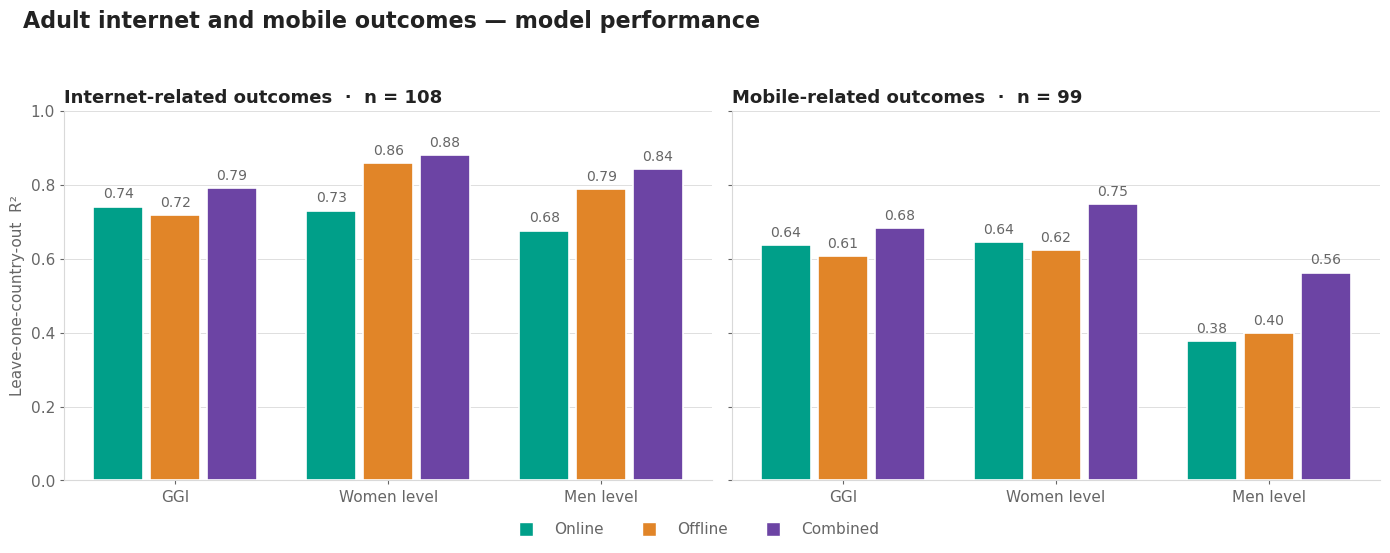

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)

series = params.FIGURE_VARIANTS
colours = dict(zip(series, plot.PALETTE))
outcomes = ['ggi', 'wom', 'men']

for ax, indicator in zip(axes, CFG['indicators']):
    block = perf[(perf['indicator'] == indicator) & (perf['variant'].isin(series))]
    values = {v: [float(block[(block['variant'] == v) & (block['outcome'] == o)]['loco_r2'].squeeze())
                  for o in outcomes] for v in series}
    plot.grouped_bars(ax, [OUTCOME_LABEL[o] for o in outcomes], series, values,
                      colours=colours, fmt='{:.2f}')
    n = int(block['n'].iloc[0])
    plot.tidy(ax, title=f'{indicator.capitalize()}-related outcomes  ·  n = {n}', grid='y')
    ax.set_ylim(0, 1.0)

axes[0].set_ylabel('Leave-one-country-out  R²', fontsize=plot.STYLE['tick_fs'], color=plot.MUTED)
plot.legend(fig, [plot.swatch(colours[v], VARIANT_LABEL[v]) for v in series], y=-0.06)
plot.suptitle(fig, 'Adult internet and mobile outcomes — model performance')
fig.tight_layout(rect=(0, 0, 1, 0.93))
plot.save(fig, NOTEBOOK, '03_01_loco_r2_by_variant')
plt.show()

### Against the originally published values

The figure this reproduces printed: internet 0.74 / 0.72 / 0.79 (GGI), 0.73 / 0.86 / 0.88 (women),
0.68 / 0.79 / 0.84 (men); mobile 0.64 / 0.61 / 0.68, 0.64 / 0.62 / 0.75, 0.38 / 0.40 / 0.56.

In [5]:
PUBLISHED = {('internet','ggi'):(0.74,0.72,0.79), ('internet','wom'):(0.73,0.86,0.88),
             ('internet','men'):(0.68,0.79,0.84), ('mobile','ggi'):(0.64,0.61,0.68),
             ('mobile','wom'):(0.64,0.62,0.75), ('mobile','men'):(0.38,0.40,0.56)}

rows = []
for (ind, out), published in PUBLISHED.items():
    got = tuple(round(float(perf[(perf['indicator'] == ind) & (perf['variant'] == v)
                                 & (perf['outcome'] == out)]['loco_r2'].squeeze()), 3)
                for v in params.FIGURE_VARIANTS)
    rows.append({'indicator': ind, 'outcome': out,
                 'published': ' / '.join(f'{v:.2f}' for v in published),
                 'recomputed': ' / '.join(f'{v:.3f}' for v in got),
                 'max_abs_diff': round(max(abs(a - b) for a, b in zip(published, got)), 3)})
check = pd.DataFrame(rows)
print(f"largest disagreement with the published figure: {check['max_abs_diff'].max():.3f}")
check

largest disagreement with the published figure: 0.005


,indicator,outcome,published,recomputed,max_abs_diff
0,internet,ggi,0.74 / 0.72 / 0.79,0.741 / 0.719 / 0.791,0.001
1,internet,wom,0.73 / 0.86 / 0.88,0.730 / 0.859 / 0.881,0.001
2,internet,men,0.68 / 0.79 / 0.84,0.676 / 0.789 / 0.843,0.004
3,mobile,ggi,0.64 / 0.61 / 0.68,0.637 / 0.607 / 0.683,0.003
4,mobile,wom,0.64 / 0.62 / 0.75,0.645 / 0.623 / 0.749,0.005
5,mobile,men,0.38 / 0.40 / 0.56,0.376 / 0.399 / 0.563,0.004


## 4. Every variant, for reference

Including the suffix-less `online` / `offline` / `combined`, which are fitted on the **71 / 75**
sample and give materially lower numbers. Reading the published figure off those is the natural
mistake (D37).

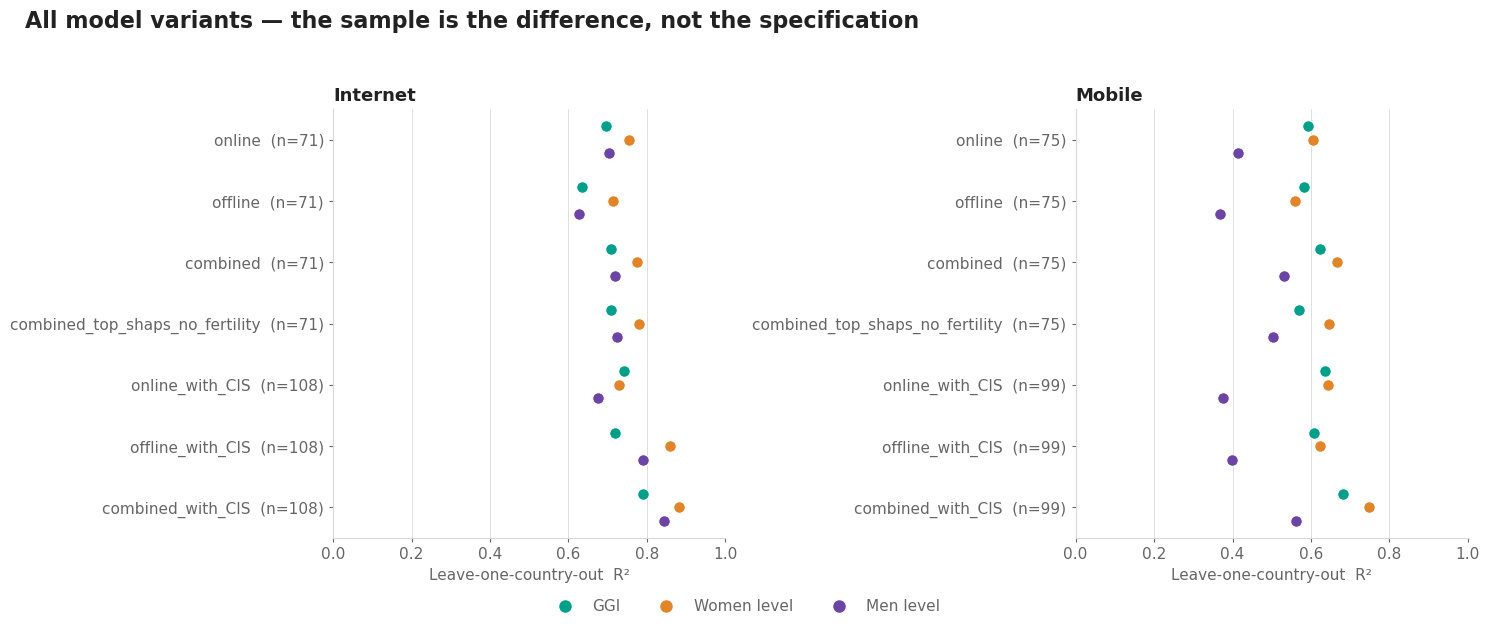

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

order = [v for v in params.MODEL_VARIANTS if not v.endswith('_align')]
for ax, indicator in zip(axes, CFG['indicators']):
    block = perf[(perf['indicator'] == indicator) & (perf['variant'].isin(order))]
    y = np.arange(len(order))
    for k, outcome in enumerate(outcomes):
        vals = [float(block[(block['variant'] == v) & (block['outcome'] == outcome)]['loco_r2'].squeeze())
                for v in order]
        ax.scatter(vals, y + (k - 1) * 0.22, s=70, color=plot.PALETTE[k],
                   edgecolor='white', linewidth=0.8, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{v}  (n={int(block[block['variant'] == v]['n'].iloc[0])})" for v in order])
    ax.set_ylim(len(order) - 0.5, -0.5)
    plot.tidy(ax, title=indicator.capitalize(), xlabel='Leave-one-country-out  R²', grid='x')
    ax.set_xlim(0, 1)

plot.legend(fig, [plot.swatch(plot.PALETTE[k], OUTCOME_LABEL[o], marker='o')
                  for k, o in enumerate(outcomes)], y=-0.05)
plot.suptitle(fig, 'All model variants — the sample is the difference, not the specification')
fig.tight_layout(rect=(0, 0, 1, 0.94))
plot.save(fig, NOTEBOOK, '03_01_loco_r2_all_variants')
plt.show()

## 5. Write the tables

In [7]:
from datetime import datetime

# The survey validation: predicted against observed, built here from the coherent-GGI series
# (an earlier stage's output) and the survey ground truth.
annual = mp.load_annual_series()
groundtruth = mp.load_groundtruth()
training_keys, training_countries = mp.load_training_keys()

gt = mp.build_groundtruth_comparison(annual, groundtruth, training_keys, training_countries)
gt_stats = mp.summarise_groundtruth(gt)
gt_levels = mp.build_groundtruth_levels(annual, groundtruth, training_keys, training_countries)
gt_level_stats = mp.summarise_groundtruth_levels(gt_levels)
unseen = mp.build_unseen_surveys(gt, gt_levels)

stamp = f'{datetime.now():%Y%m%d}'
for name, frame in [('model_performance', perf), ('model_verification', checks),
                    ('model_performance_groundtruth', gt),
                    ('model_performance_groundtruth_stats', gt_stats),
                    ('model_performance_groundtruth_levels', gt_levels),
                    ('model_performance_groundtruth_level_stats', gt_level_stats),
                    ('model_performance_unseen_surveys', unseen)]:
    path = params.table_dir(NOTEBOOK) / f'{name}_{stamp}.csv'
    frame.to_csv(path, index=False)
    print(f'{path.name:56s} {len(frame):5d} rows')

gt_stats.round(4)


ground truth: update_full_groundtruth_20260812.csv (90 country-years)
model_performance_20260817.csv                              60 rows
model_verification_20260817.csv                             90 rows
model_performance_groundtruth_20260817.csv                 531 rows
model_performance_groundtruth_stats_20260817.csv            24 rows
model_performance_groundtruth_levels_20260817.csv          354 rows
model_performance_groundtruth_level_stats_20260817.csv      16 rows
model_performance_unseen_surveys_20260817.csv               34 rows


,indicator,definition,sample,n_dropped_zero_floor,n,bias,mae,rmse,r2,within_0.05,within_0.10,pearson_r,spearman_r
0,internet,coherent_parity,all,0,88,0.0210,0.1165,0.1498,0.5911,28.4091,52.2727,0.7938,0.8512
1,internet,coherent_parity,in_training,0,71,0.0153,0.1163,0.1511,0.6076,28.1690,53.5211,0.8036,0.8503
2,internet,coherent_parity,held_out,0,17,0.0446,0.1174,0.1439,0.3816,29.4118,47.0588,0.6659,0.8056
3,internet,coherent_parity,held_out_new_country,0,4,0.0529,0.0529,0.0641,0.8087,50.0000,75.0000,0.9886,0.9487
4,internet,coherent_raw,all,0,88,0.0216,0.1161,0.1494,0.5929,28.4091,53.4091,0.7956,0.8513
5,internet,coherent_raw,in_training,0,71,0.0159,0.1157,0.1507,0.6101,28.1690,54.9296,0.8057,0.8503
6,internet,coherent_raw,held_out,0,17,0.0454,0.1182,0.1442,0.3786,29.4118,47.0588,0.6656,0.8039
7,internet,coherent_raw,held_out_new_country,0,4,0.0560,0.0560,0.0674,0.7884,50.0000,75.0000,0.9818,0.8000
8,internet,direct,all,0,88,-0.0029,0.0951,0.1174,0.7489,29.5455,65.9091,0.8668,0.8661
9,internet,direct,in_training,0,71,-0.0004,0.0956,0.1179,0.7614,29.5775,64.7887,0.8748,0.8651


## Notes

- LOCO R² is pooled (`1 − RSS/TSS`) over held-out predictions, not the mean of per-fold R²: with
  one to three rows per country a per-fold R² is undefined.
- `doc/modelling.md` is the written account — the spec, every filter, the ten variants and the
  three misleading names.
- The survey validation of these predictions is `03_02_unseen_survey_validation.ipynb`.